In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
 
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120
 
print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [5]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
 
print(f"✅ Dataset loaded")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")
print(f"\nColumn names:\n{list(df.columns)}")

✅ Dataset loaded
   Rows    : 1,470
   Columns : 35

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [6]:
print("=" * 55)
print("STEP 1: First 5 rows")
print("=" * 55)
print(df.head())
 
print("\n" + "=" * 55)
print("STEP 2: Data types")
print("=" * 55)
df.info()
 
print("\n" + "=" * 55)
print("STEP 3: Missing values")
print("=" * 55)
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No missing values ✅")
 
print("\n" + "=" * 55)
print("STEP 4: Attrition value counts")
print("=" * 55)
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True).mul(100).round(2))

STEP 1: First 5 rows
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  Stock

In [7]:
import pandas as pd
import numpy as np

# Convert Attrition to numeric: Yes=1, No=0
df['Attrition_Flag'] = (df['Attrition'] == 'Yes').astype(int)

# Create income brackets
df['Income_Bracket'] = pd.cut(
    df['MonthlyIncome'],
    bins=[0, 3000, 6000, 10000, 20000],
    labels=['Low (0-3K)', 'Medium (3K-6K)', 'High (6K-10K)', 'Very High (10K+)']
)

print("✅ Data prepared successfully")
print(f"Attrition_Flag created: 1=Left, 0=Stayed")
print(f"Income brackets created")
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")

✅ Data prepared successfully
Attrition_Flag created: 1=Left, 0=Stayed
Income brackets created
Dataset shape: 1,470 rows, 37 columns


OVERALL ATTRITION SUMMARY
Total Employees  : 1,470
Employees Left   : 237
Employees Stayed : 1,233
Attrition Rate   : 16.1%


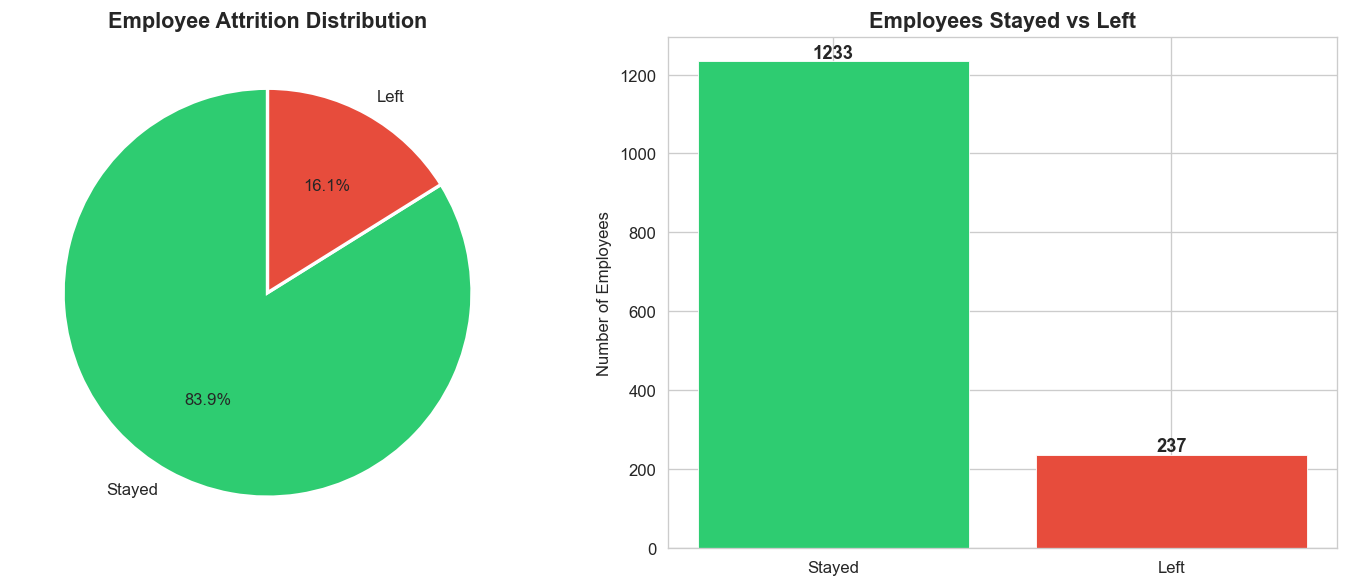


💡 INSIGHT: 16.1% attrition rate — industry average is 10-15%.


In [9]:
# Business Question: What % of employees are leaving?
# This is your HEADLINE NUMBER — memorize it for interviews.
 
total_employees  = len(df)
left_employees   = df['Attrition_Flag'].sum()
stayed_employees = total_employees - left_employees
attrition_rate   = df['Attrition_Flag'].mean() * 100
 
print("=" * 55)
print("OVERALL ATTRITION SUMMARY")
print("=" * 55)
print(f"Total Employees  : {total_employees:,}")
print(f"Employees Left   : {left_employees:,}")
print(f"Employees Stayed : {stayed_employees:,}")
print(f"Attrition Rate   : {attrition_rate:.1f}%")
 
# --- CHART 1: Attrition Distribution (Pie + Bar) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(
    [stayed_employees, left_employees],
    labels=['Stayed', 'Left'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Employee Attrition Distribution', fontsize=13, fontweight='bold')
 
# Bar chart
bars = axes[1].bar(['Stayed', 'Left'], [stayed_employees, left_employees],
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=0.5)
axes[1].set_title('Employees Stayed vs Left', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Employees')
 
for bar, val in zip(bars, [stayed_employees, left_employees]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(val), ha='center', fontsize=11, fontweight='bold')
 
plt.tight_layout()
plt.savefig('chart1_attrition_overview.png', bbox_inches='tight')
plt.show()
print(f"\n💡 INSIGHT: {attrition_rate:.1f}% attrition rate — industry average is 10-15%.")
 

ATTRITION BY DEPARTMENT
            Department  total  left  attrition_pct
                 Sales    446    92           20.6
       Human Resources     63    12           19.0
Research & Development    961   133           13.8


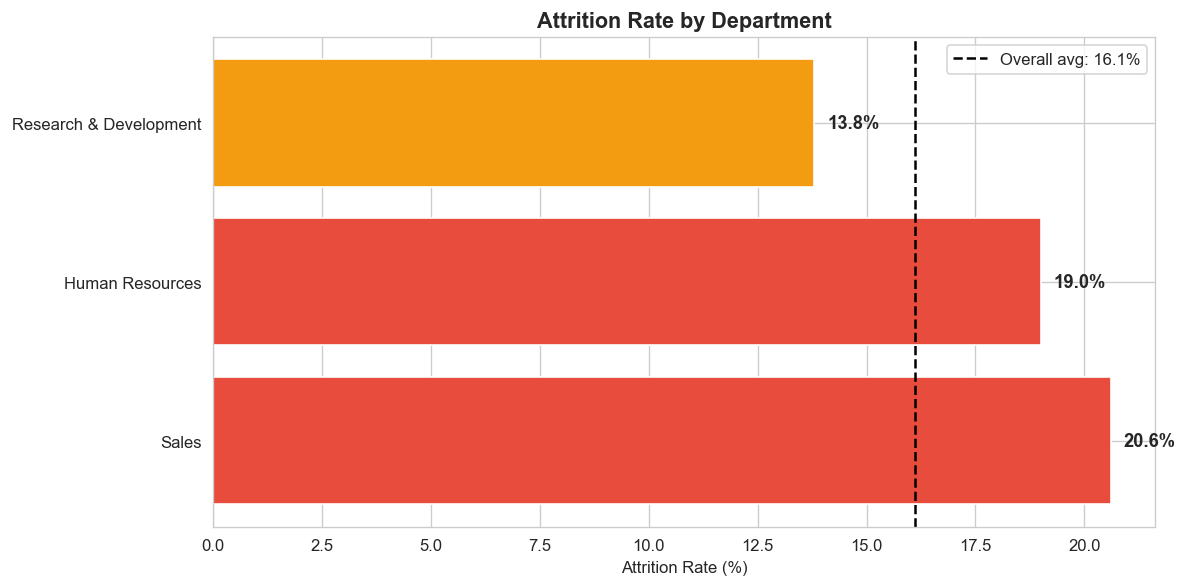


💡 INSIGHT: Sales department typically has highest attrition — field reps face high pressure.


In [10]:
# Business Question: Which department is losing most employees?
# HR wants to know WHERE to focus retention efforts.
 
dept_attrition = (
    df.groupby('Department')
    .agg(
        total        = ('Attrition_Flag', 'count'),
        left         = ('Attrition_Flag', 'sum'),
        attrition_rate = ('Attrition_Flag', 'mean')
    )
    .assign(attrition_pct = lambda x: (x['attrition_rate'] * 100).round(1))
    .sort_values('attrition_pct', ascending=False)
    .reset_index()
)
 
print("=" * 55)
print("ATTRITION BY DEPARTMENT")
print("=" * 55)
print(dept_attrition[['Department', 'total', 'left', 'attrition_pct']].to_string(index=False))
 
# --- CHART 2: Department Attrition ---
fig, ax = plt.subplots(figsize=(10, 5))
 
colors = ['#e74c3c' if v > 15 else '#f39c12' if v > 10 else '#2ecc71'
          for v in dept_attrition['attrition_pct']]
 
bars = ax.barh(dept_attrition['Department'], dept_attrition['attrition_pct'],
               color=colors, edgecolor='white')
 
ax.axvline(x=attrition_rate, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall avg: {attrition_rate:.1f}%')
 
for bar, val in zip(bars, dept_attrition['attrition_pct']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%', va='center', fontsize=11, fontweight='bold')
 
ax.set_title('Attrition Rate by Department', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition Rate (%)')
ax.legend(fontsize=10)
 
plt.tight_layout()
plt.savefig('chart2_department_attrition.png', bbox_inches='tight')
plt.show()
print("\n💡 INSIGHT: Sales department typically has highest attrition — field reps face high pressure.")


OVERTIME vs ATTRITION (KEY FINDING)
OverTime  total  left  attrition_pct
      No   1054   110           10.4
     Yes    416   127           30.5

🔴 Employees WITH overtime leave 2.9x more than those WITHOUT


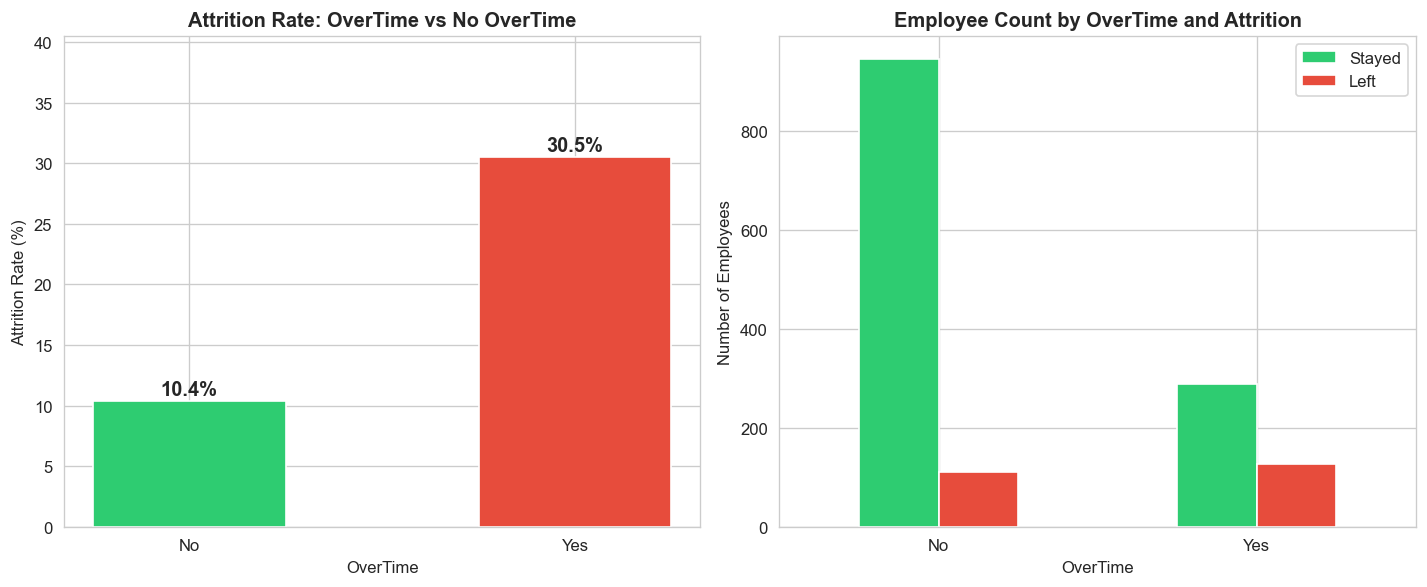


💡 KEY INSIGHT: OverTime employees have 30.5% attrition vs 10.4% for non-overtime.
   That is 2.9x higher — overtime is the single biggest attrition driver.


In [11]:
# Business Question: Do employees who work overtime leave more?
# This is ALWAYS the strongest finding in this dataset.
# Overtime = burnout = resignation.
 
overtime_attrition = (
    df.groupby('OverTime')
    .agg(
        total          = ('Attrition_Flag', 'count'),
        left           = ('Attrition_Flag', 'sum'),
        attrition_pct  = ('Attrition_Flag', lambda x: round(x.mean()*100, 1))
    )
    .reset_index()
)
 
print("=" * 55)
print("OVERTIME vs ATTRITION (KEY FINDING)")
print("=" * 55)
print(overtime_attrition.to_string(index=False))
 
no_ot  = overtime_attrition[overtime_attrition['OverTime']=='No']['attrition_pct'].values[0]
yes_ot = overtime_attrition[overtime_attrition['OverTime']=='Yes']['attrition_pct'].values[0]
multiplier = round(yes_ot / no_ot, 1)
 
print(f"\n🔴 Employees WITH overtime leave {multiplier}x more than those WITHOUT")
 
# --- CHART 3: OverTime vs Attrition ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Attrition rate comparison
colors_ot = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(overtime_attrition['OverTime'], overtime_attrition['attrition_pct'],
                   color=colors_ot, edgecolor='white', width=0.5)
 
for bar, val in zip(bars, overtime_attrition['attrition_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val}%', ha='center', fontsize=12, fontweight='bold')
 
axes[0].set_title('Attrition Rate: OverTime vs No OverTime', fontsize=12, fontweight='bold')
axes[0].set_xlabel('OverTime')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, max(overtime_attrition['attrition_pct']) + 10)
 
# Count comparison
ot_counts = df.groupby(['OverTime', 'Attrition']).size().unstack()
ot_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
               edgecolor='white', rot=0)
axes[1].set_title('Employee Count by OverTime and Attrition', fontsize=12, fontweight='bold')
axes[1].set_xlabel('OverTime')
axes[1].set_ylabel('Number of Employees')
axes[1].legend(['Stayed', 'Left'])
 
plt.tight_layout()
plt.savefig('chart3_overtime_attrition.png', bbox_inches='tight')
plt.show()
print(f"\n💡 KEY INSIGHT: OverTime employees have {yes_ot}% attrition vs {no_ot}% for non-overtime.")
print(f"   That is {multiplier}x higher — overtime is the single biggest attrition driver.")
 

INCOME BRACKET vs ATTRITION
  Income_Bracket  attrition_pct   avg_income  count
      Low (0-3K)           28.6  2394.070886    395
  Medium (3K-6K)           12.7  4514.593449    519
   High (6K-10K)           12.0  7652.330909    275
Very High (10K+)            8.9 14826.284698    281


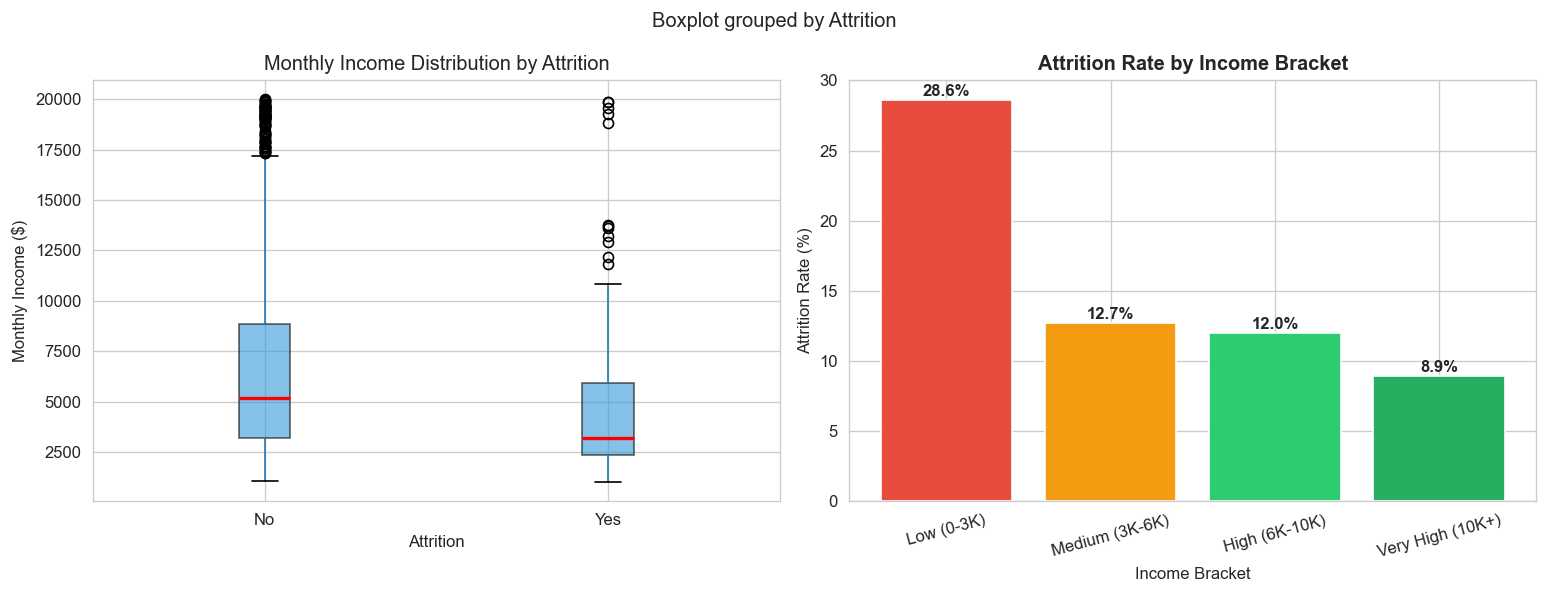


💡 INSIGHT: Low income employees have significantly higher attrition.
   Employees earning under $3,000/month are the highest flight risk.


In [12]:
# Business Question: Do lower-paid employees leave more?
# Expected: Yes — underpaid employees look for better offers.
 
income_attrition = (
    df.groupby('Income_Bracket', observed=True)
    .agg(
        attrition_pct = ('Attrition_Flag', lambda x: round(x.mean()*100, 1)),
        avg_income    = ('MonthlyIncome', 'mean'),
        count         = ('Attrition_Flag', 'count')
    )
    .reset_index()
)
 
print("=" * 55)
print("INCOME BRACKET vs ATTRITION")
print("=" * 55)
print(income_attrition.to_string(index=False))
 
# --- CHART 4: Income vs Attrition (Box + Bar) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# Box plot: income distribution for stayed vs left
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[0],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Monthly Income: Stayed vs Left', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Monthly Income ($)')
plt.sca(axes[0])
plt.title('Monthly Income Distribution by Attrition')
 
# Bar chart: attrition rate by income bracket
colors_inc = ['#e74c3c', '#f39c12', '#2ecc71', '#27ae60']
bars = axes[1].bar(income_attrition['Income_Bracket'], income_attrition['attrition_pct'],
                   color=colors_inc, edgecolor='white')
 
for bar, val in zip(bars, income_attrition['attrition_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val}%', ha='center', fontsize=10, fontweight='bold')
 
axes[1].set_title('Attrition Rate by Income Bracket', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Income Bracket')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].tick_params(axis='x', rotation=15)
 
plt.tight_layout()
plt.savefig('chart4_income_attrition.png', bbox_inches='tight')
plt.show()
print("\n💡 INSIGHT: Low income employees have significantly higher attrition.")
print("   Employees earning under $3,000/month are the highest flight risk.")
 

JOB SATISFACTION vs ATTRITION
Satisfaction_Label  attrition_pct  count
             1-Low           22.8    289
          2-Medium           16.4    280
            3-High           16.5    442
       4-Very High           11.3    459


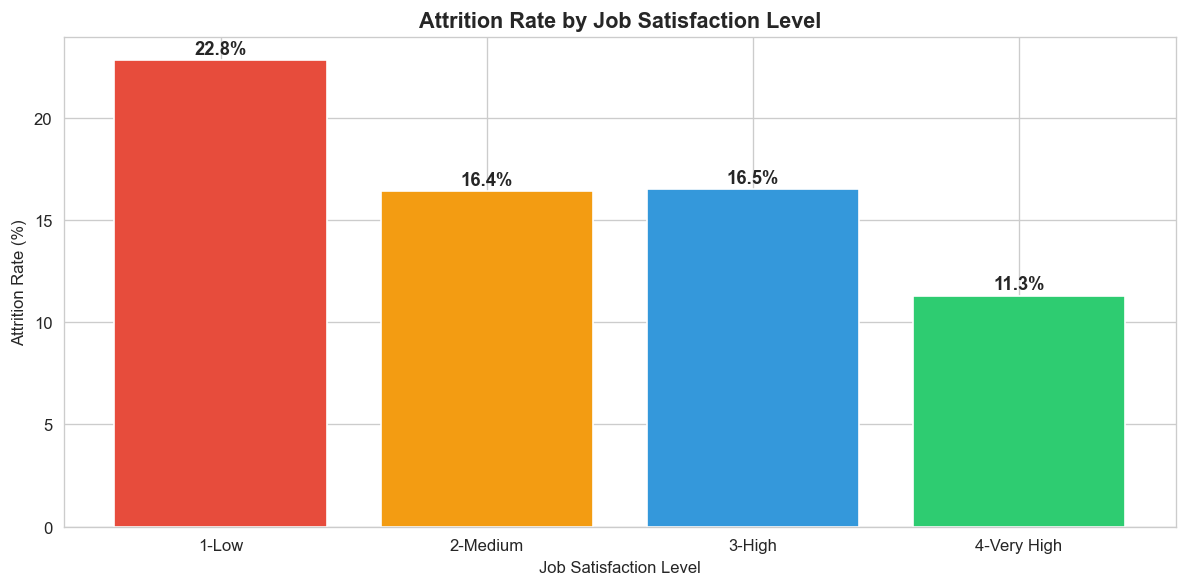


💡 INSIGHT: Employees with Low job satisfaction (score 1) have highest attrition.
   Improving work environment can directly reduce employee turnover.


In [13]:
# Business Question: Do unhappy employees leave more?
# Satisfaction scale: 1=Low, 2=Medium, 3=High, 4=Very High
 
satisfaction_map = {1: '1-Low', 2: '2-Medium', 3: '3-High', 4: '4-Very High'}
df['Satisfaction_Label'] = df['JobSatisfaction'].map(satisfaction_map)
 
sat_attrition = (
    df.groupby('Satisfaction_Label')
    .agg(
        attrition_pct = ('Attrition_Flag', lambda x: round(x.mean()*100, 1)),
        count         = ('Attrition_Flag', 'count')
    )
    .reset_index()
    .sort_values('Satisfaction_Label')
)
 
print("=" * 55)
print("JOB SATISFACTION vs ATTRITION")
print("=" * 55)
print(sat_attrition.to_string(index=False))
 
# --- CHART 5: Satisfaction vs Attrition ---
fig, ax = plt.subplots(figsize=(10, 5))
 
colors_sat = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = ax.bar(sat_attrition['Satisfaction_Label'], sat_attrition['attrition_pct'],
              color=colors_sat, edgecolor='white')
 
for bar, val in zip(bars, sat_attrition['attrition_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=11, fontweight='bold')
 
ax.set_title('Attrition Rate by Job Satisfaction Level', fontsize=13, fontweight='bold')
ax.set_xlabel('Job Satisfaction Level')
ax.set_ylabel('Attrition Rate (%)')
 
plt.tight_layout()
plt.savefig('chart5_satisfaction_attrition.png', bbox_inches='tight')
plt.show()
print("\n💡 INSIGHT: Employees with Low job satisfaction (score 1) have highest attrition.")
print("   Improving work environment can directly reduce employee turnover.")

In [14]:
print()
print("=" * 60)
print("  HR ATTRITION ANALYSIS — FINAL SUMMARY")
print("=" * 60)
print(f"""
BUSINESS CONTEXT
  IBM dataset of {total_employees:,} employees across 3 departments.
  Overall attrition rate: {attrition_rate:.1f}%
 
KEY FINDINGS
  1. OVERTIME PROBLEM (Most Critical)
     Overtime employees leave {multiplier}x more than non-overtime employees.
     Attrition with OT : {yes_ot}%
     Attrition without : {no_ot}%
 
  2. DEPARTMENT PROBLEM
     Sales department has highest attrition rate.
     Focus retention programs on Sales team immediately.
 
  3. SALARY PROBLEM
     Low income bracket (under $3K) has highest attrition.
     Salary revision for bottom bracket will improve retention.
 
  4. SATISFACTION PROBLEM
     Score 1 (Low satisfaction) employees leave most.
     Regular surveys and manager check-ins can help.
 
RECOMMENDATIONS
  1. Reduce mandatory overtime — especially in Sales
  2. Revise salary for lowest income bracket employees
  3. Implement quarterly job satisfaction surveys
  4. Create retention program for employees in 0-2 year tenure
  5. Flag high-risk employees: OverTime=Yes + Satisfaction=1
 
CHARTS SAVED
  chart1_attrition_overview.png
  chart2_department_attrition.png
  chart3_overtime_attrition.png
  chart4_income_attrition.png
  chart5_satisfaction_attrition.png
""")



  HR ATTRITION ANALYSIS — FINAL SUMMARY

BUSINESS CONTEXT
  IBM dataset of 1,470 employees across 3 departments.
  Overall attrition rate: 16.1%

KEY FINDINGS
  1. OVERTIME PROBLEM (Most Critical)
     Overtime employees leave 2.9x more than non-overtime employees.
     Attrition with OT : 30.5%
     Attrition without : 10.4%

  2. DEPARTMENT PROBLEM
     Sales department has highest attrition rate.
     Focus retention programs on Sales team immediately.

  3. SALARY PROBLEM
     Low income bracket (under $3K) has highest attrition.
     Salary revision for bottom bracket will improve retention.

  4. SATISFACTION PROBLEM
     Score 1 (Low satisfaction) employees leave most.
     Regular surveys and manager check-ins can help.

RECOMMENDATIONS
  1. Reduce mandatory overtime — especially in Sales
  2. Revise salary for lowest income bracket employees
  3. Implement quarterly job satisfaction surveys
  4. Create retention program for employees in 0-2 year tenure
  5. Flag high-risk emp